# 1) 👤 **Integrantes:**

 Alumno:
* 1)
* 2)
* 3) Edgar Ivan Morin Gargate

# 2) 📊 **Trabajo Final de Curso — Telco Customer Churn**
### Problema de Clasificación

**Objetivo:** Predecir si un cliente de una empresa de telecomunicaciones va a cancelar su servicio (`Churn = Yes`) o no (`Churn = No`).

**Modelos a usar:**
1. KNN — K-Nearest Neighbors (Benchmark)
2. Regresión Logística (Modelo Tradicional)
3. Árbol de Decisión
4. Random Forest

---

## 📒 **Diccionario de Datos:**

| #  | Variable           | Tipo    | Descripción | Valores |
|----|-------------------|---------|-------------|---------|
| 1  | customerID        | object  | Identificador único del cliente | Texto |
| 2  | gender            | object  | Género del cliente | Male, Female |
| 3  | SeniorCitizen     | int64   | Indica si el cliente es adulto mayor | 0 = No, 1 = Sí |
| 4  | Partner           | object  | Si el cliente tiene pareja | Yes, No |
| 5  | Dependents        | object  | Si el cliente tiene dependientes | Yes, No |
| 6  | tenure            | int64   | Meses de permanencia en la empresa | Numérico |
| 7  | PhoneService      | object  | Servicio telefónico | Yes, No |
| 8  | MultipleLines     | object  | Múltiples líneas telefónicas | Yes, No, No phone service |
| 9  | InternetService   | object  | Tipo de internet | DSL, Fiber optic, No |
| 10 | OnlineSecurity    | object  | Seguridad online | Yes, No, No internet service |
| 11 | OnlineBackup      | object  | Respaldo online | Yes, No, No internet service |
| 12 | DeviceProtection  | object  | Protección de dispositivo | Yes, No, No internet service |
| 13 | TechSupport       | object  | Soporte técnico | Yes, No, No internet service |
| 14 | StreamingTV       | object  | TV en streaming | Yes, No, No internet service |
| 15 | StreamingMovies   | object  | Películas en streaming | Yes, No, No internet service |
| 16 | Contract          | object  | Tipo de contrato | Month-to-month, One year, Two year |
| 17 | PaperlessBilling  | object  | Facturación sin papel | Yes, No |
| 18 | PaymentMethod     | object  | Método de pago | Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic) |
| 19 | MonthlyCharges    | float64 | Cargo mensual del cliente | Numérico |
| 20 | TotalCharges      | object  | Cargo total acumulado (convertir a numérico) | String → float |
| 21 | Churn             | object  | Variable objetivo (abandono del cliente) | Yes, No |

In [2]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


## **0. Instalación de Librerías**

In [1]:
# Instalación (solo si no tienes las librerías)
# !pip install pandas numpy matplotlib seaborn scikit-learn

# — Manejo de datos —
import pandas as pd
import numpy as np
import math

# — Visualización —
import matplotlib.pyplot as plt
import seaborn as sns

# — Preprocesamiento —
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# — Modelos —
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# — Evaluación —
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# — Configuración visual —
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectFromModel

# **1. Carga de datos**

In [3]:
# Cargar el dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# **2. Análisis Exploratorio (EDA)**



## **a) Información general**


### (a.1) Dimensión

In [4]:
df.shape

(7043, 21)

### (a.2) Columnas

In [5]:
# Veamos que tipos de variables son nuestros datos, y su cantidad también
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### (a.3) Cantidad de Valores únicos

In [6]:
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


### (a.4) Primer Resumen estadístico (variables numéricas)

In [7]:
# Estadísticas descriptivas de columnas numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## **b) Valores nulos**

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## **c) Distribuciones (numéricas y categóricas)**


### c.1) Veamos conteo de variables object, para ver el comportamiento

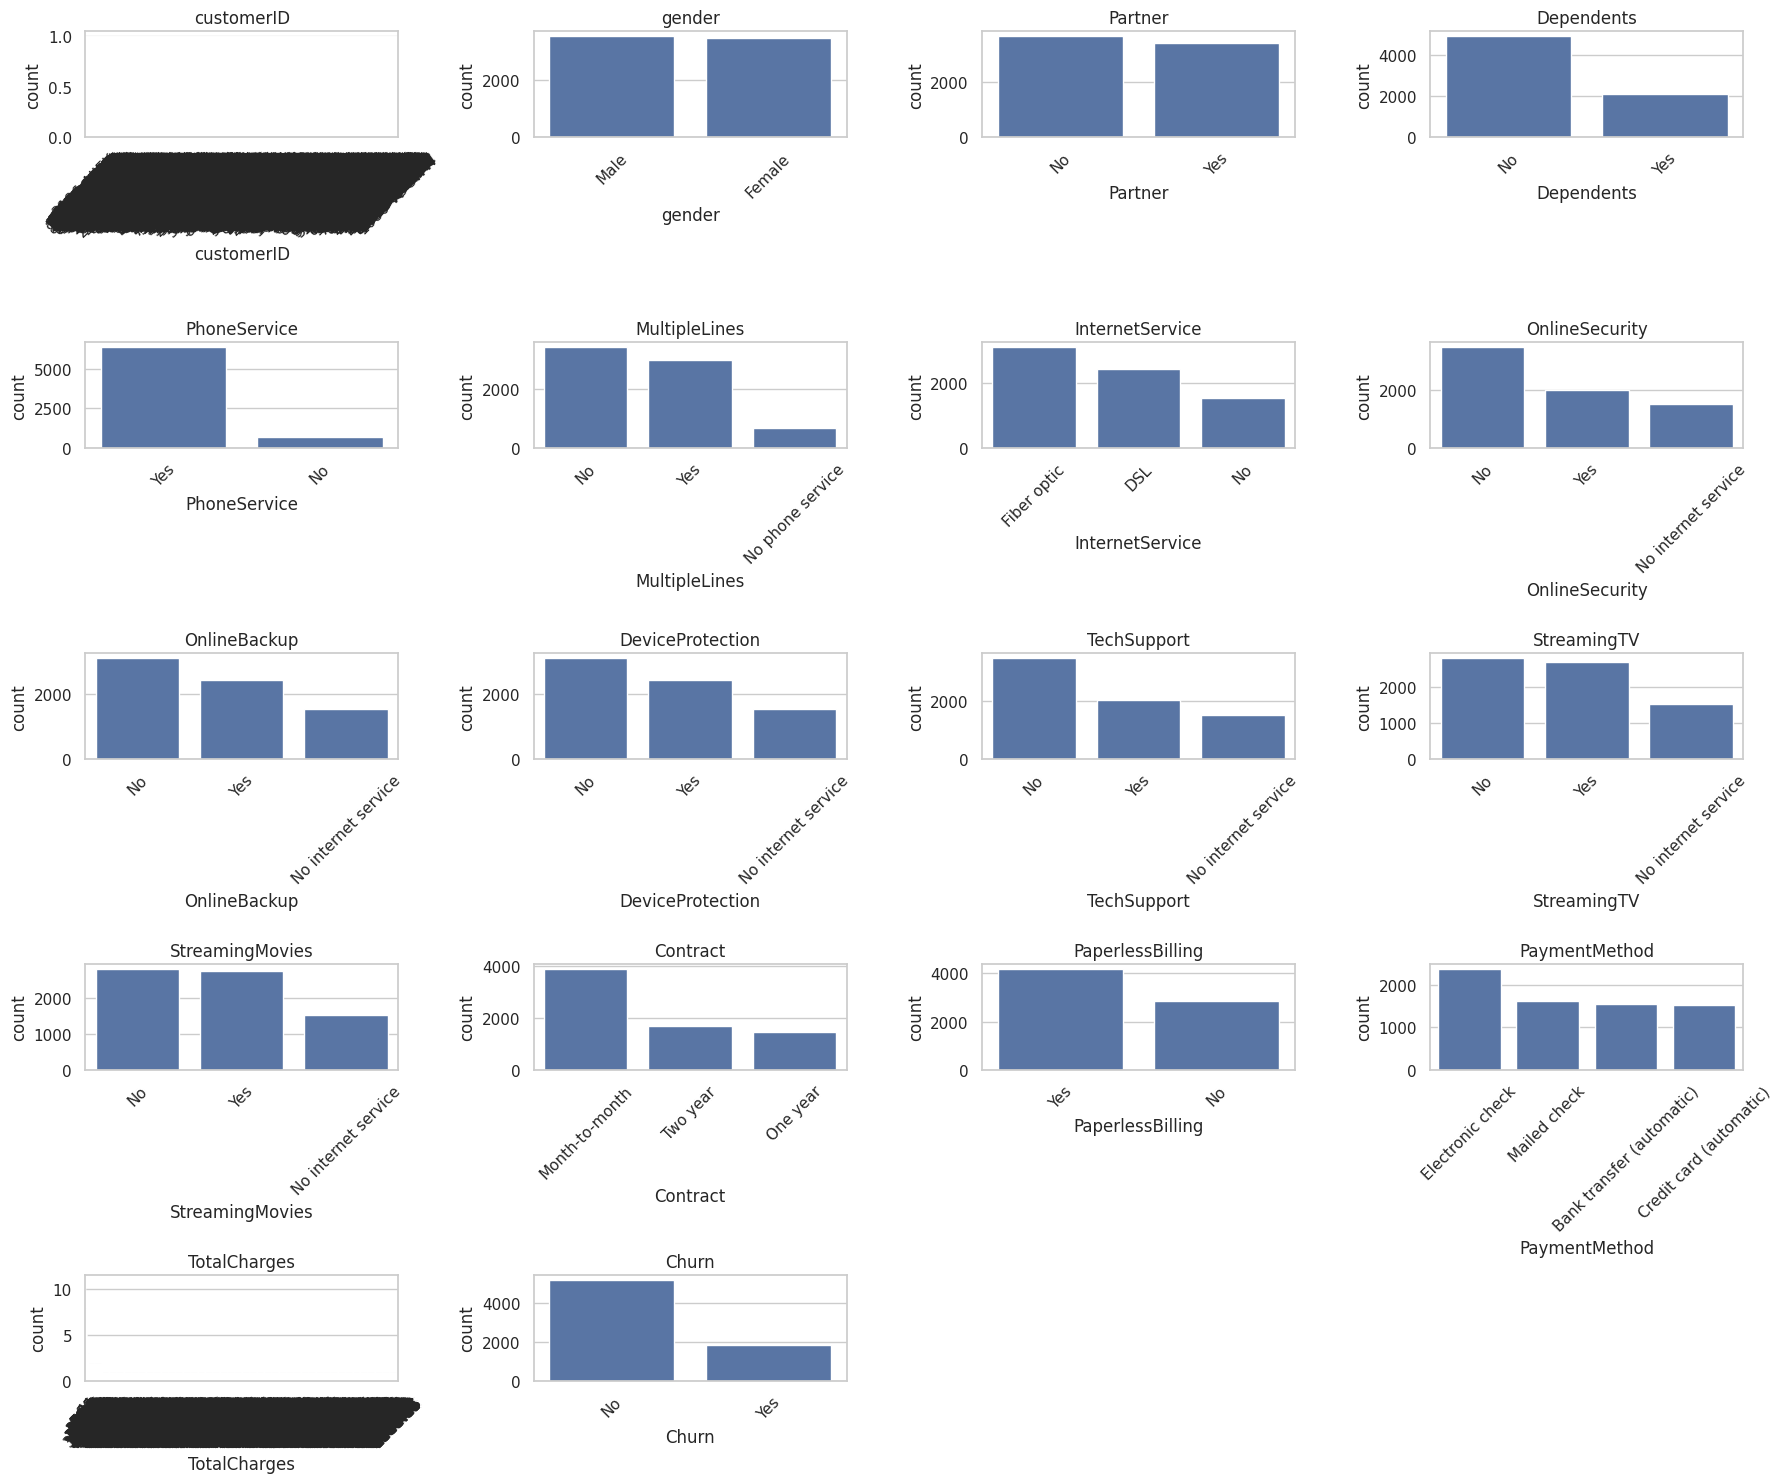

In [9]:
# Seleccionar variables categóricas
categorical_columns = df.select_dtypes(include=['object']).columns

# Crear figura
plt.figure(figsize=(18, 15))

for idx, col in enumerate(categorical_columns, 1):
    plt.subplot(5, 4, idx)
    sns.countplot(x=df[col], order=df[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(f"{col}")

plt.tight_layout()
plt.show()

* La variable predictora `gender` no muestra mucha variabilidad.
* Observamos que `TotalCharges` no presenta una estructura definida. Revisemos algo más.

In [10]:
df['TotalCharges'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 7043 entries, 0 to 7042
Series name: TotalCharges
Non-Null Count  Dtype 
--------------  ----- 
7043 non-null   object
dtypes: object(1)
memory usage: 55.2+ KB


In [11]:
df['TotalCharges'].head(5)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65


Observamos que la variable `TotalCharges` es numérica, sin embargo está definida como tipo `object`. En los siguientes pasos se realizará el tratamiento respectivo.

### c.2) Veamos conteo de variables numéricas, para ver el comportamiento

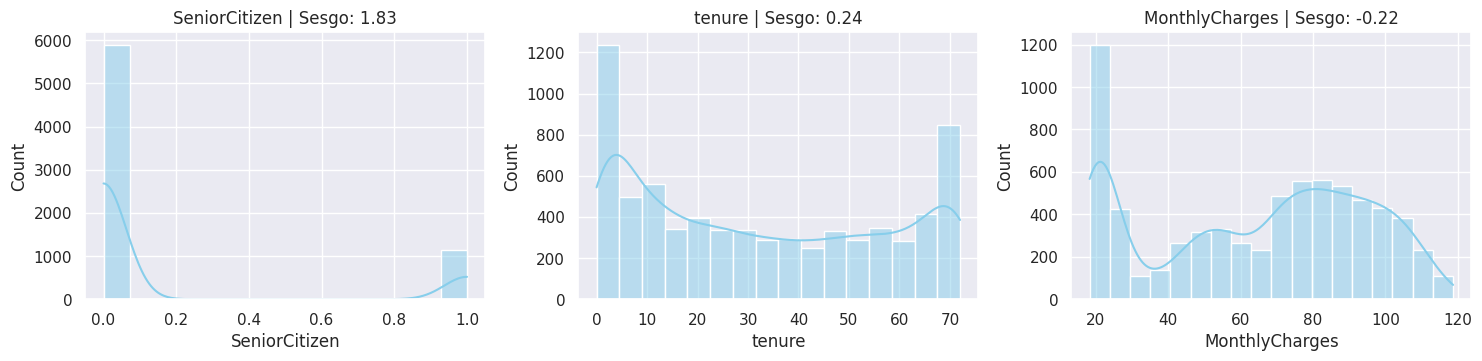

In [12]:
# Estilo
sns.set_style("darkgrid")

# Seleccionar variables numéricas
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Crear figura
plt.figure(figsize=(15, 10))

for idx, col in enumerate(numerical_columns, 1):
    plt.subplot(3, 3, idx)
    sns.histplot(df[col], kde=True, color='skyblue')
    sesgo = round(df[col].skew(), 2)
    plt.title(f"{col} | Sesgo: {sesgo}")

plt.tight_layout()
plt.show()

* **SeniorCitizen** es una variable categórica binaria (adulto mayor). Ya viene definida numéricamente.
* **tenure** (meses de permanencia) podría agruparse para evitar desbalance marcado.
* **MonthlyCharges** es el monto mensual que la empresa cobra al cliente por el servicio.


## **d) Descripciones (numéricas y categóricas)**



### d.1) Numéricas

In [13]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    print("\n//=======================")
    print(f"VARIABLE NUMÉRICA: {col}")
    print("//=======================")
    print("Nulos:", df[col].isnull().sum())
    print("Tipo:", df[col].dtype)
    print("Cardinalidad:", df[col].nunique())
    print("\nResumen estadístico:")
    print(df[col].describe())
    print("\nTop valores:")
    print(df[col].value_counts(dropna=False).head())


//=======================
VARIABLE NUMÉRICA: SeniorCitizen
//=======================
Nulos: 0
Tipo: int64
Cardinalidad: 2

Resumen estadístico:
count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: SeniorCitizen, dtype: float64

Top valores:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

//=======================
VARIABLE NUMÉRICA: tenure
//=======================
Nulos: 0
Tipo: int64
Cardinalidad: 73

Resumen estadístico:
count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

Top valores:
tenure
1     613
72    362
2     238
3     200
4     176
Name: count, dtype: int64

//=======================
VARIABLE NUMÉRICA: MonthlyCharges
//=======================
Nulos: 0
Tipo: float64
Cardinalidad: 1585

Resumen estadí

### d.2) Categóricas

In [14]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    print("\n//=======================")
    print(f"VARIABLE CATEGÓRICA: {col}")
    print("//=======================")
    print("Nulos:", df[col].isnull().sum())
    print("Tipo:", df[col].dtype)
    print("Cardinalidad:", df[col].nunique())
    print("\nFrecuencia de valores:")
    print(df[col].value_counts(dropna=False).head(10))


//=======================
VARIABLE CATEGÓRICA: customerID
//=======================
Nulos: 0
Tipo: object
Cardinalidad: 7043

Frecuencia de valores:
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
4501-VCPFK    1
6075-SLNIL    1
9347-AERRL    1
0093-XWZFY    1
2274-XUATA    1
1980-KXVPM    1
7703-ZEKEF    1
Name: count, dtype: int64

//=======================
VARIABLE CATEGÓRICA: gender
//=======================
Nulos: 0
Tipo: object
Cardinalidad: 2

Frecuencia de valores:
gender
Male      3555
Female    3488
Name: count, dtype: int64

//=======================
VARIABLE CATEGÓRICA: Partner
//=======================
Nulos: 0
Tipo: object
Cardinalidad: 2

Frecuencia de valores:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

//=======================
VARIABLE CATEGÓRICA: Dependents
//=======================
Nulos: 0
Tipo: object
Cardinalidad: 2

Frecuencia de valores:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

//=======================
VARIABLE C

`TotalCharges` presenta valores vacíos. Analizando los datos, se concluye que son clientes nuevos que aún no han completado un mes de servicio.

# **3) Pretratamiento de datos**

## a) Convertimos `TotalCharges` a variable numérica

In [15]:
# Convertimos TotalCharges a numérica
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Los 11 valores vacíos corresponden a clientes nuevos entonces le asignamos 0
df.loc[df["TotalCharges"].isnull(), "TotalCharges"] = 0

In [16]:
# Verificamos los 11 clientes nuevos con TotalCharges = 0
df[df["TotalCharges"]==0][["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,0.0
753,3115-CZMZD,0,20.25,0.0
936,5709-LVOEQ,0,80.85,0.0
1082,4367-NUYAO,0,25.75,0.0
1340,1371-DWPAZ,0,56.05,0.0
3331,7644-OMVMY,0,19.85,0.0
3826,3213-VVOLG,0,25.35,0.0
4380,2520-SGTTA,0,20.00,0.0
5218,2923-ARZLG,0,19.70,0.0
6670,4075-WKNIU,0,73.35,0.0


## a) Pretratamiento de Duplicados

In [17]:
print(f"Filas totales originales: {len(df)}")

duplicados_mask = df.duplicated(keep='first')
n_duplicados = duplicados_mask.sum()

print(f"Número de filas duplicadas: {n_duplicados}")

Filas totales originales: 7043
Número de filas duplicadas: 0


In [18]:
if n_duplicados > 0:
    display(df[duplicados_mask].head())

df = df.drop_duplicates(keep='first')
print(f"Filas luego de eliminar duplicados: {len(df)}")

Filas luego de eliminar duplicados: 7043


In [19]:
# Gráfico de nulos por variable
cols_null_vals = df.isnull().sum() * 100 / df.shape[0]
cols_null_vals = cols_null_vals[cols_null_vals != 0].sort_values(ascending=False)

if len(cols_null_vals) > 0:
    plt.figure(figsize=(12,8))
    sns.barplot(x=cols_null_vals.values, y=cols_null_vals.index, palette="magma")
    plt.xlabel("Porcentaje de valores nulos (%)")
    plt.ylabel("Variables")
    plt.title("Porcentaje de valores nulos por variable")
    plt.xlim(0, 100)
    plt.show()
else:
    print("No hay valores nulos en el dataset.")

No hay valores nulos en el dataset.


In [20]:
# Eliminamos la variable ID ya que solo es un identificador
df = df.drop(columns=['customerID'])
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## b) Pretratamiento de Missing

In [21]:
def var_percent(df):
    cols_null_vals = df.isnull().sum(axis=0)
    cols_null_vals = (100 * cols_null_vals) / df.shape[0]
    cols_null_vals = cols_null_vals[cols_null_vals != 0]
    cols_nulls = cols_null_vals.sort_values(ascending=False)
    if len(cols_nulls) > 0:
        print('Porcentaje de Nulos por Variable:')
        print(cols_nulls)
    else:
        print('No hay nulos por variable')

def null_percent(df):
    total_nulls = (100 * df.isnull().sum().sum()) / (df.shape[0] * df.shape[1])
    print(f'Porcentaje Total de Nulos = {total_nulls:.4f}%')

var_percent(df)
null_percent(df)

No hay nulos por variable
Porcentaje Total de Nulos = 0.0000%


**Para el tratamiento de outliers, se podría aplicar una winsorización al 5%-95%:**

$$X_i = \begin{cases} q_{0.05}, & \text{si } X_i < q_{0.05} \\ X_i, & \text{si } q_{0.05} \le X_i \le q_{0.95} \\ q_{0.95}, & \text{si } X_i > q_{0.95} \end{cases}$$

En este problema de churn **no se aplicó winsorización** porque los valores extremos representan comportamiento real del cliente y no errores de medición. Recortarlos podría eliminar señal relevante para el modelo.

## **c) Distribuciones gráficas con target**


### **(c.1) Variables numéricas vs Churn**


**i) Diagrama de Boxplots**

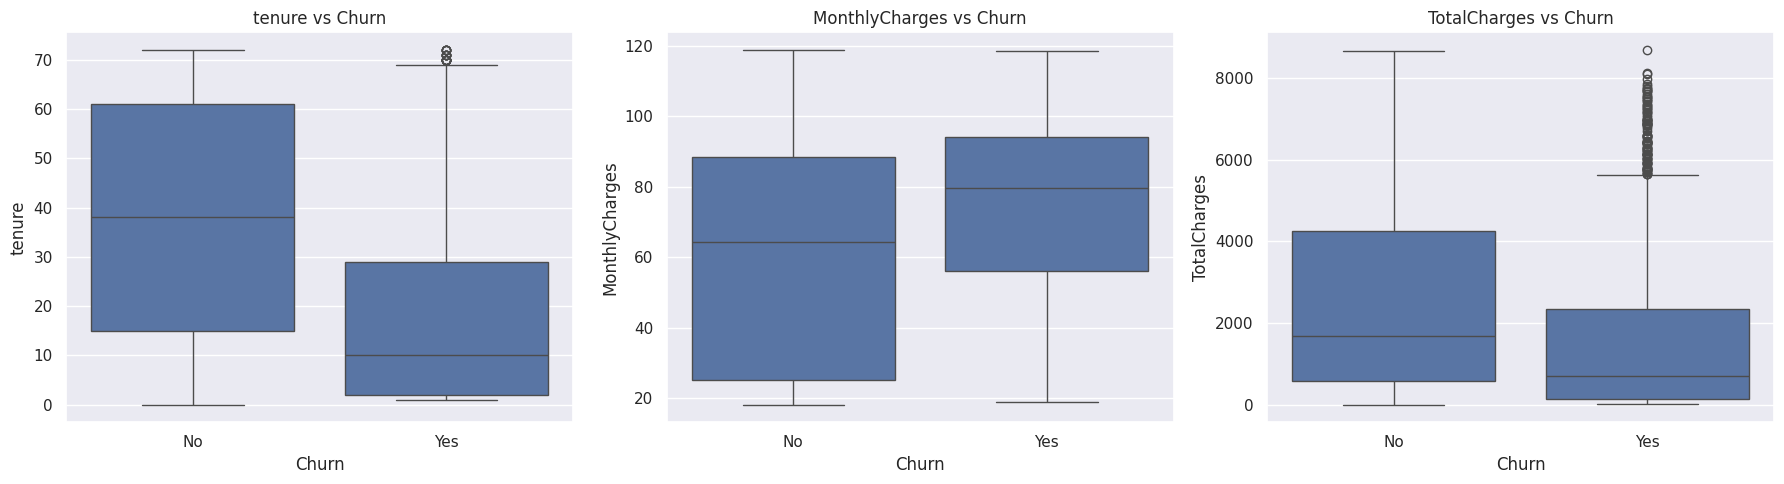

In [22]:
num_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, var in enumerate(num_vars):
    sns.boxplot(x="Churn", y=var, data=df, ax=axes[i])
    axes[i].set_title(f"{var} vs Churn")

plt.tight_layout()
plt.show()

No se consideró la variable `SeniorCitizen` pues es una variable binaria.

**ii) Diagrama de barras**

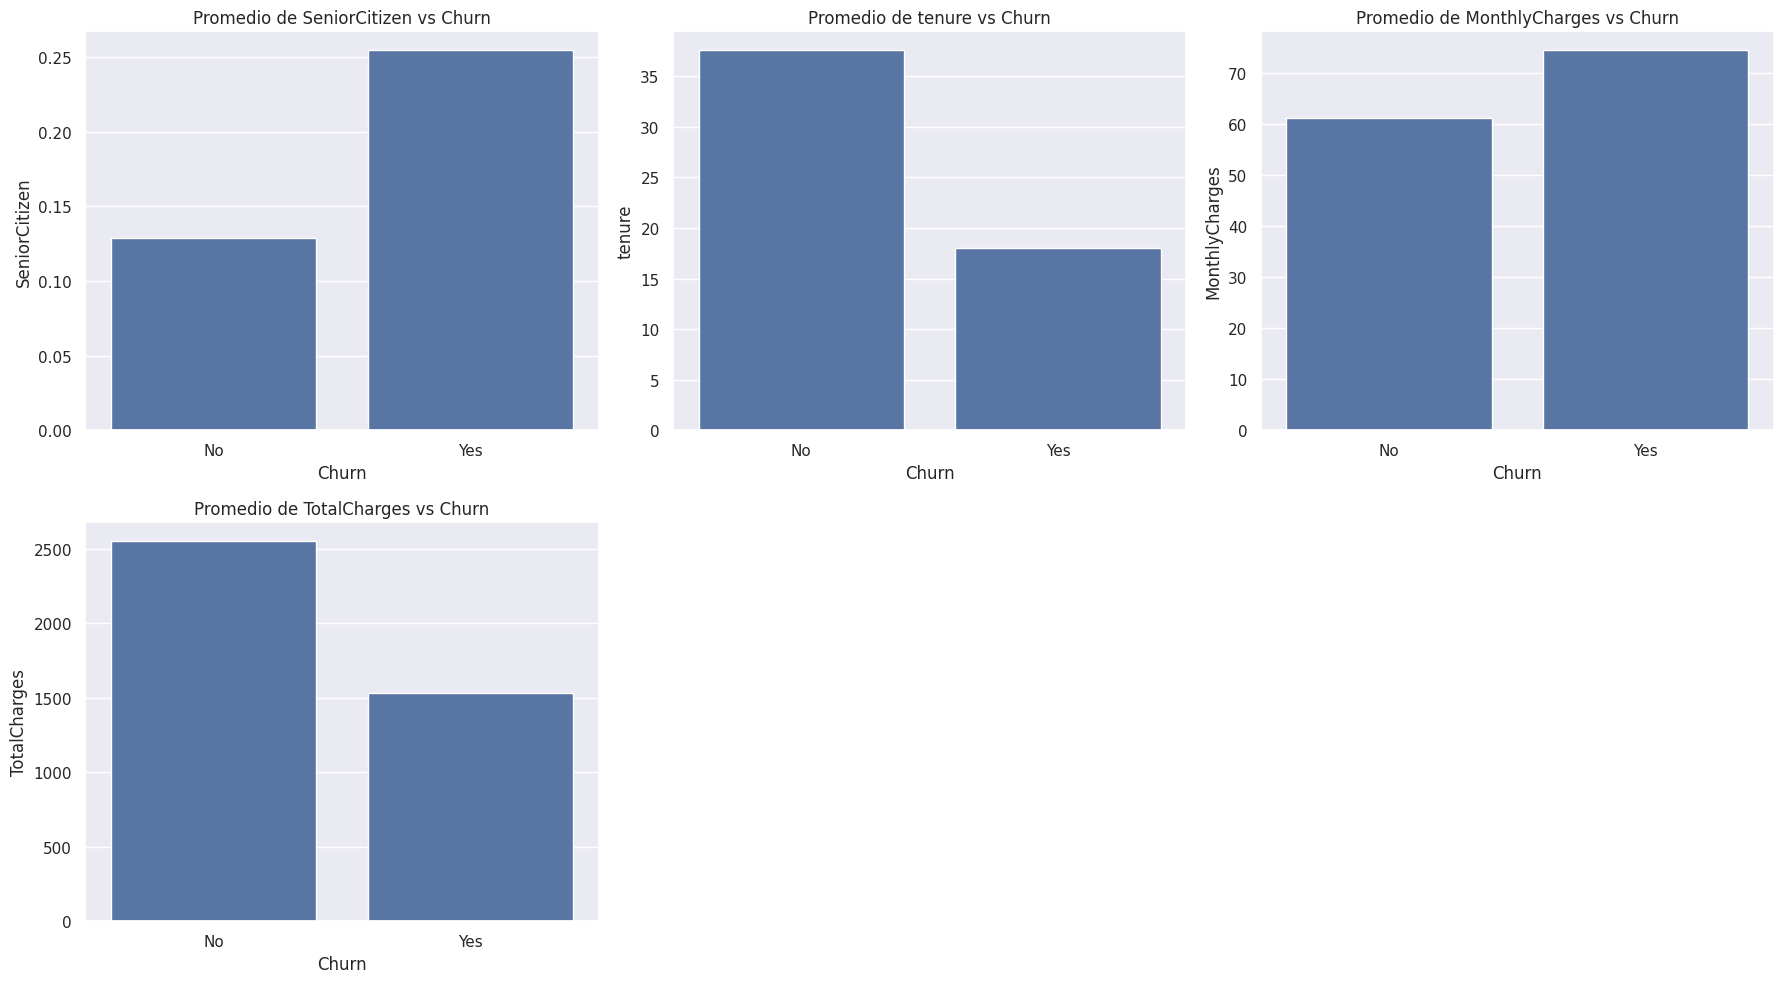

In [23]:
num_vars = df.select_dtypes(include=["int64", "float64"]).columns
num_vars = num_vars.drop("Churn", errors="ignore")

n_cols = 3
n_rows = math.ceil(len(num_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_vars):
    df_grouped = df.groupby("Churn")[col].mean().reset_index()
    sns.barplot(data=df_grouped, x="Churn", y=col, ax=axes[i])
    axes[i].set_title(f"Promedio de {col} vs Churn")

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**iii) Distribución binned por rango**

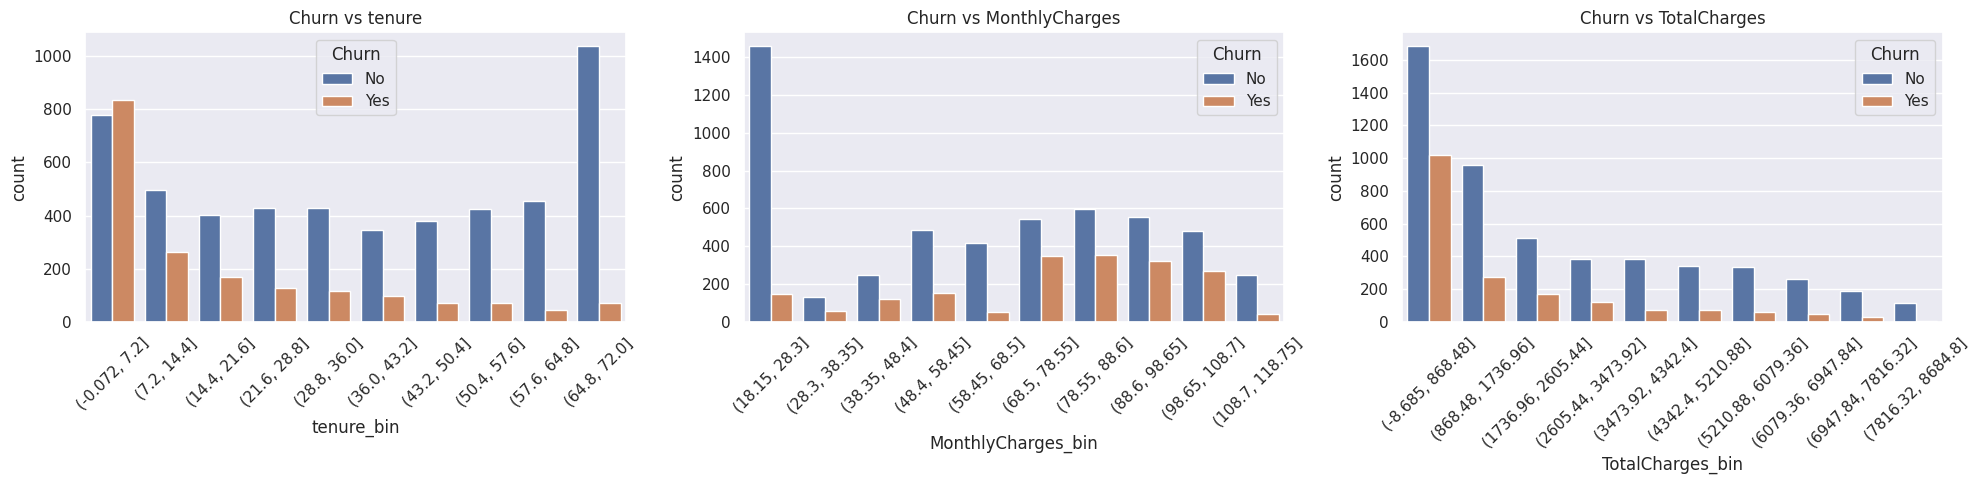

In [24]:
num_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

df_plot = df.copy()
for col in num_vars:
    df_plot[col + "_bin"] = pd.cut(df_plot[col], bins=10)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(num_vars):
    sns.countplot(x=col + "_bin", hue="Churn", data=df_plot, ax=axes[i])
    axes[i].set_title(f"Churn vs {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

del df_plot

* **Churn vs tenure**: Los clientes nuevos son mucho más propensos a abandonar. Con más meses de permanencia, la fidelización aumenta.
* **Churn vs MonthlyCharges**: Planes más baratos tienden a retener al cliente; con planes costosos hay mayor riesgo de churn.
* **TotalCharges ≈ tenure × MonthlyCharges**: La mayoría de clientes se concentra en montos acumulados bajos.



### **(c.2) Variables Object vs Churn**

**Diagrama de barras**

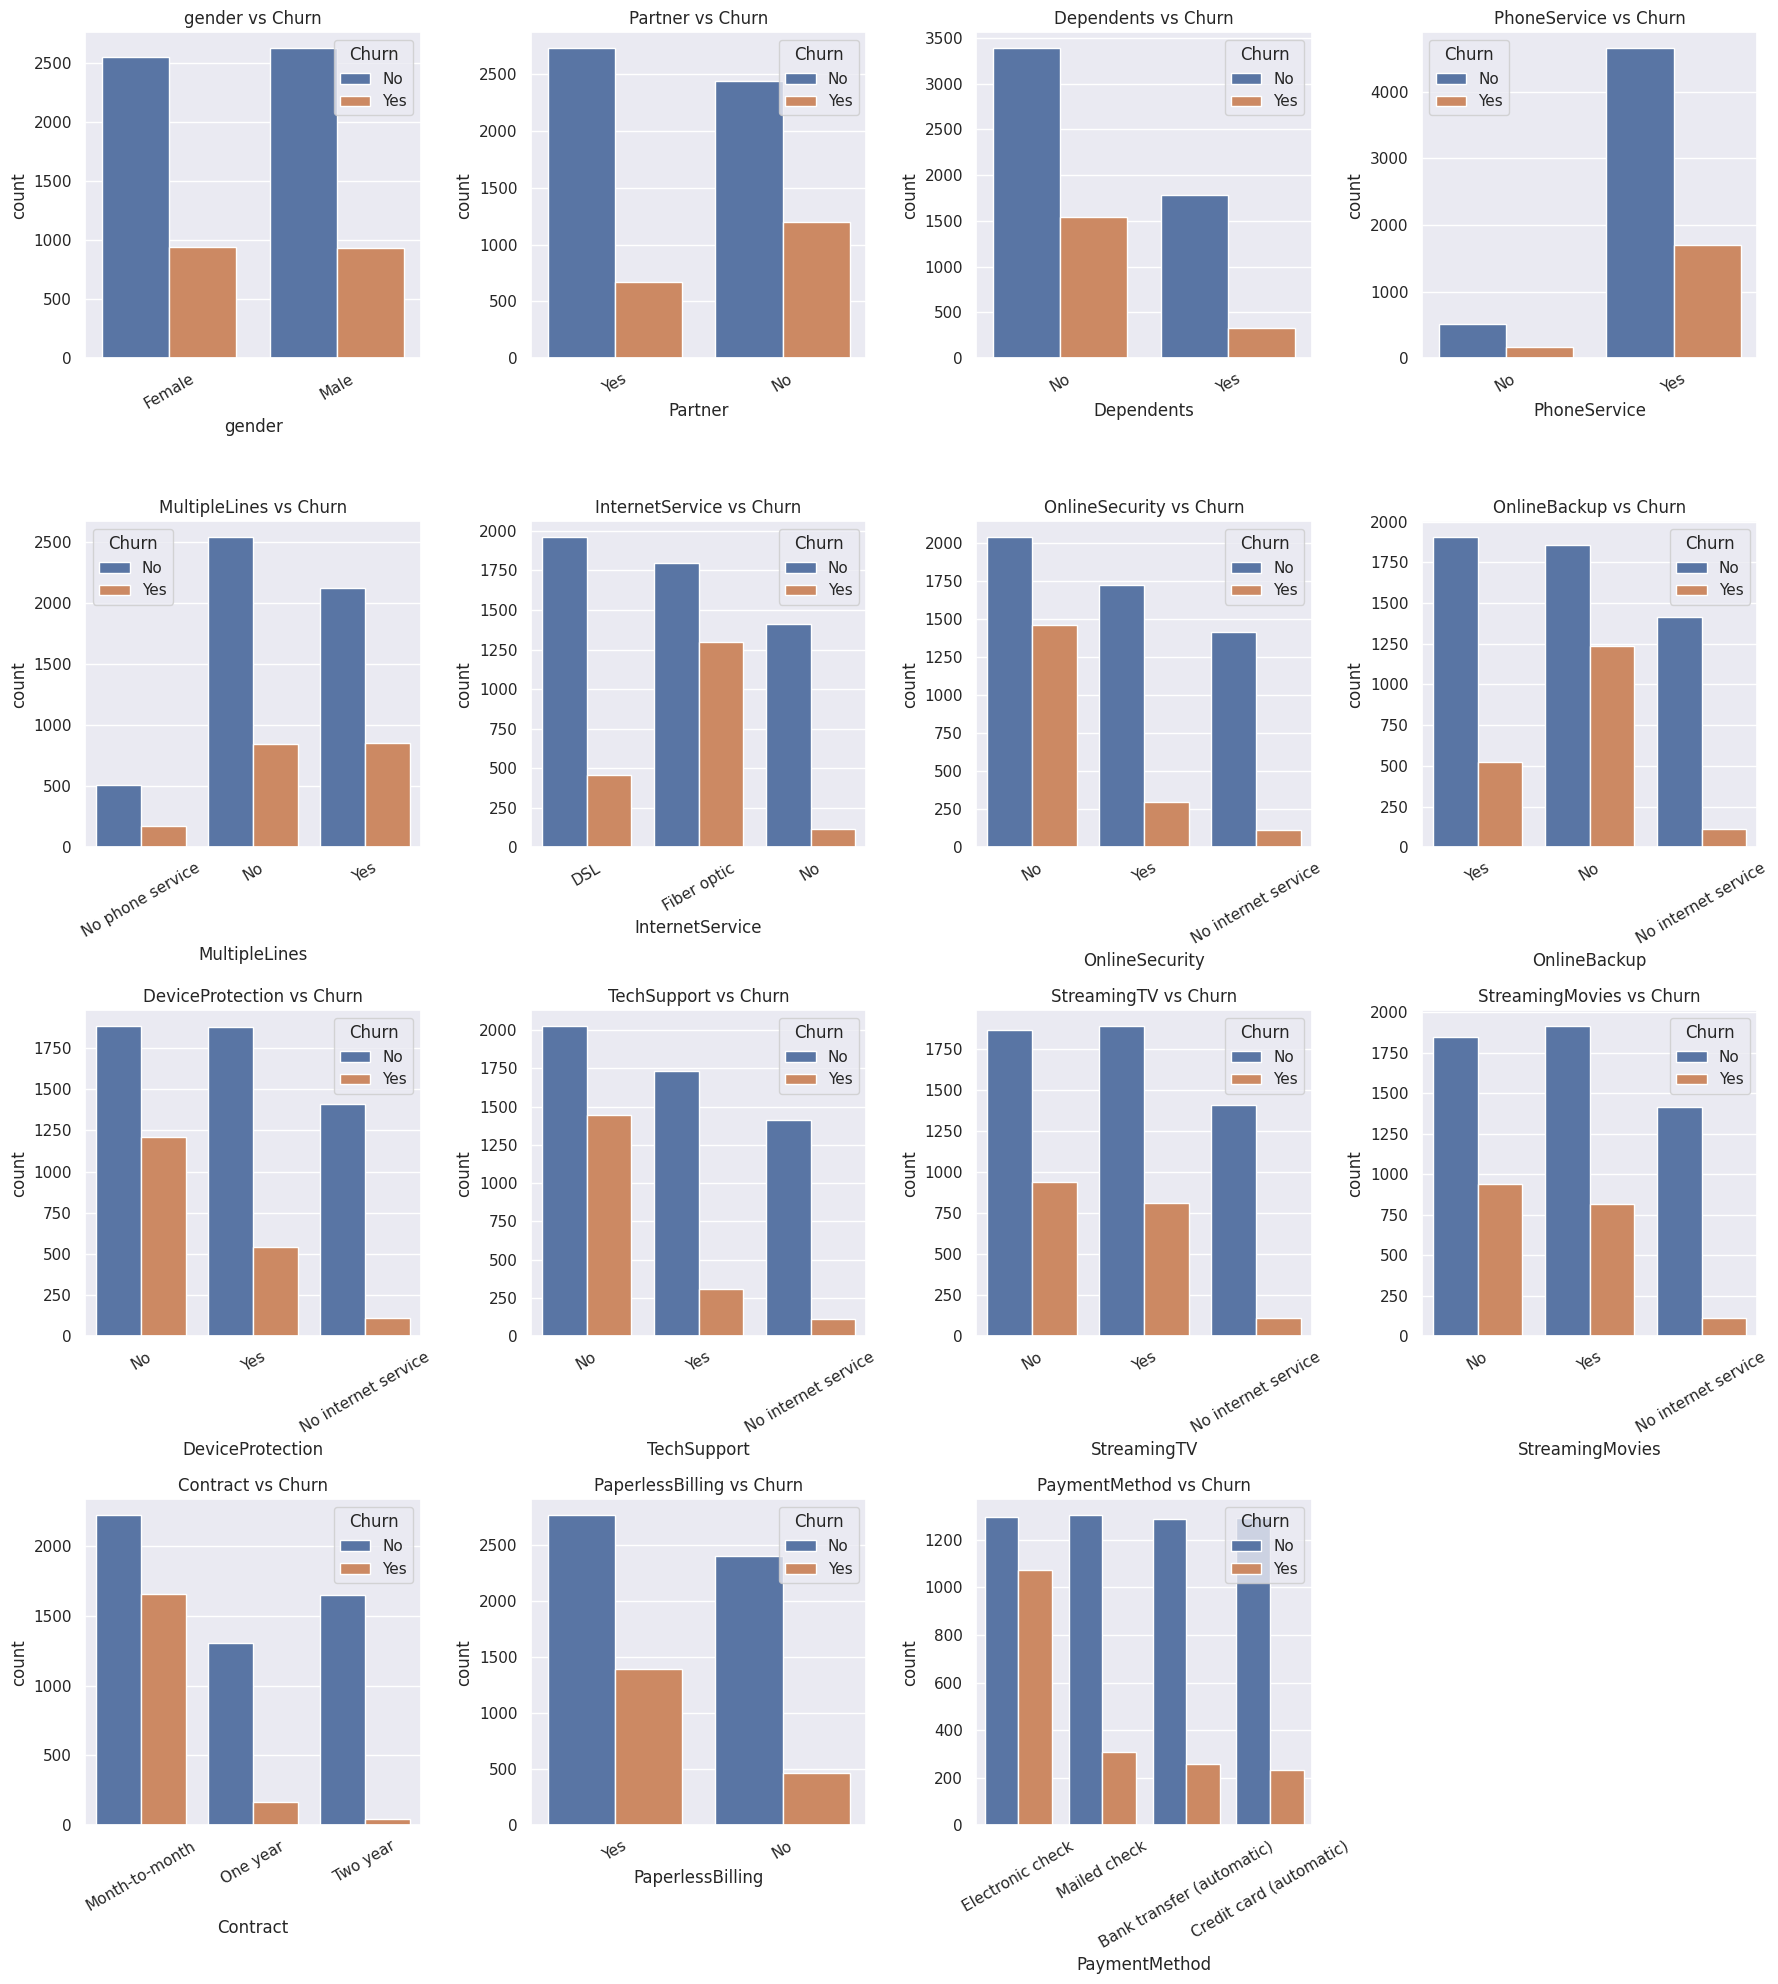

In [25]:
cat_vars = df.select_dtypes(include="object").columns
cat_vars = cat_vars.drop("Churn")

n_cols = 4
n_rows = math.ceil(len(cat_vars) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    sns.countplot(data=df, x=col, hue="Churn", ax=axes[i])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

**Diagrama de tablas cruzadas**

`SeniorCitizen` es variable binaria:

In [26]:
pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


In [27]:
cat_vars = df.select_dtypes(include="object").columns

for col in cat_vars:
    print("\n======================")
    print(f"VARIABLE: {col}")
    print("======================")
    display(pd.crosstab(df[col], df["Churn"], normalize="index"))


VARIABLE: gender


Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603



VARIABLE: Partner


Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649



VARIABLE: Dependents


...

Churn,No,Yes
PaperlessBilling,,
No,0.836699,0.163301
Yes,0.664349,0.335651



VARIABLE: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067



VARIABLE: Churn


Churn,No,Yes
Churn,,
No,1.0,0.0
Yes,0.0,1.0


* `gender` no muestra variabilidad relevante → candidata a ser eliminada.

* Variables como `OnlineSecurity`, `OnlineBackup`, `TechSupport`, `StreamingTV`, `StreamingMovies` tienen la categoría `No internet service` que es equivalente a `No` (ausencia del servicio).

* `MultipleLines` tiene `No phone service` que equivale a `No`.



# **4) Tratamientos de datos**

## a) Variables Numéricas — Análisis de correlación

Según el paso **(3.b)**, las variables numéricas se encuentran completas; y, de acuerdo con los pasos **(2.d)** y **(3.c)**, se ha determinado que no requieren tratamiento adicional.

## b) Variables Object

### **(i) Categóricas — Normalización**

Unificamos categorías equivalentes para simplificar:
- `No internet service` → `No`
- `No phone service` → `No`

In [28]:
# Variables asociadas al servicio de internet
internet_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in internet_cols:
    df[col] = df[col].replace('No internet service', 'No')

# Variable asociada al servicio telefónico
df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


# **5) Creacion de Features Enginniers**

## a) Primera fase

FEATURES ANTES DE DUMMIES / BINARIZACIÓN

In [30]:
# A. Cliente de alto valor (riesgo)
df['high_monthly'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# B. Cliente nuevo (muy importante)
df['is_new_customer'] = (df['tenure'] < 12).astype(int)

# C. Método de pago riesgoso
df['is_electronic_payment'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

# D. Internet fibra (alto churn típico)
df['has_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)

# E. Sin internet
df['no_internet'] = (df['InternetService'] == 'No').astype(int)

# F. Cliente con contrato estable
df['is_long_contract'] = (df['Contract'] != 'Month-to-month').astype(int)

## b) Codificación de variables

DUMMIES / BINARIZACIÓN

**Binarias**

In [31]:
binary_cols = [
    'gender','Partner','Dependents','PhoneService',
    'MultipleLines','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV',
    'StreamingMovies','PaperlessBilling'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

**Dummies**

In [32]:
df = pd.get_dummies(df, columns=[
    'Contract',
    'InternetService',
    'PaymentMethod'
], drop_first=True)

## c) Segunda fase

FEATURES DESPUÉS DE DUMMIES / BINARIZACIÓN

In [33]:
# A. Intensidad de servicios (MUY IMPORTANTE)
services = [
    'PhoneService','MultipleLines','OnlineSecurity',
    'OnlineBackup','DeviceProtection','TechSupport',
    'StreamingTV','StreamingMovies'
]

df['num_services'] = df[services].sum(axis=1)


# B. Perfil básico de usuario
df['is_basic_user'] = (df['num_services'] <= 2).astype(int)


# C. Riesgo combinado (alto costo + bajo uso)
df['high_cost_low_usage'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['num_services'] <= 2)
).astype(int)


# D. Valor real del cliente
df['avg_monthly_real'] = df['TotalCharges'] / (df['tenure'] + 1)


# E. Consistencia de facturación (gap entre esperado y real)
df['expected_total'] = df['MonthlyCharges'] * df['tenure']
df['charges_gap'] = df['TotalCharges'] - df['expected_total']


# F. Baja lealtad (alto riesgo de churn)
df['low_loyalty'] = (
    (df['tenure'] < 6) & (df['num_services'] <= 2)
).astype(int)

# **6) Limpieza Final**

In [34]:
df = df.drop(columns=[
    'is_long_contract',
    'is_new_customer',
    'high_monthly'
])

# **7) TARGET (OBLIGATORIO)**

In [35]:
df['target_bin'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 35 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 0 non-null      float64
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   MultipleLines                          7043 non-null   int64  
 7   OnlineSecurity                         7043 non-null   int64  
 8   OnlineBackup                           7043 non-null   int64  
 9   DeviceProtection                       7043 non-null   int64  
 10  TechSupport                            7043 non-null   int64  
 11  Stre

In [37]:
# 1. Fix gender (o eliminar si está mal)
df = df.drop(columns=['gender'])

# 2. Eliminar target original
df = df.drop(columns=['Churn'])

# 3. Convertir bool a int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   Partner                                7043 non-null   int64  
 2   Dependents                             7043 non-null   int64  
 3   tenure                                 7043 non-null   int64  
 4   PhoneService                           7043 non-null   int64  
 5   MultipleLines                          7043 non-null   int64  
 6   OnlineSecurity                         7043 non-null   int64  
 7   OnlineBackup                           7043 non-null   int64  
 8   DeviceProtection                       7043 non-null   int64  
 9   TechSupport                            7043 non-null   int64  
 10  StreamingTV                            7043 non-null   int64  
 11  Stre

# **8) Seleccion de Variables**

SELECCIÓN DE VARIABLES (RANDOM FOREST)

In [41]:
# 1. Base de datos (solo para selección)
X_base = df.drop(columns=['target_bin'])
y = df['target_bin']

# 2. Modelo para importancia de variables
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_base, y)

# 3. Selector automático
selector = SelectFromModel(rf, threshold="median")
selector.fit(X_base, y)

# 4. Variables seleccionadas
selected_features = X_base.columns[selector.get_support()].tolist()

print("Variables seleccionadas:", len(selected_features))

Variables seleccionadas: 16


CREAR DATAFRAME REDUCIDO

In [42]:
df_selected = df[selected_features + ['target_bin']]

# **9) Modelado**

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.svm import SVC
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay
)

In [44]:
X = df_selected.drop(columns=['target_bin'])
y = df_selected['target_bin']

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print("\nDistribución:")
print(y.value_counts(normalize=True))

Shape X: (7043, 16)
Shape y: (7043,)

Distribución:
target_bin
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [45]:
def get_scores(modelo, X):
    """
    Devuelve score para ROC-AUC.
    - predict_proba si existe (Logistic, RF, etc.)
    - decision_function si no existe (SVM)
    """
    if hasattr(modelo, "predict_proba"):
        return modelo.predict_proba(X)[:, 1]
    else:
        return modelo.decision_function(X)


def evaluar_modelo(y_true, y_pred, y_score, nombre="Modelo"):
    """
    Evalúa modelo con métricas + matriz de confusión + reporte.
    Devuelve DataFrame con métricas.
    """

    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score,
        f1_score, roc_auc_score, classification_report,
        ConfusionMatrixDisplay
    )
    import pandas as pd
    import matplotlib.pyplot as plt

    metricas = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1-score":  f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_true, y_score),
    }

    df_met = pd.DataFrame([metricas]).round(4)

    # Matriz de confusión
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"Matriz de Confusión — {nombre}")
    plt.tight_layout()
    plt.show()

    # Reporte
    print(f"\nClassification Report — {nombre}")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["No Churn", "Churn"]
        )
    )

    return df_met

In [46]:
# CV objects — se usan en todos los modelos
# outer_cv: evalúa el rendimiento real (5 folds)
# inner_cv: selecciona hiperparámetros dentro del train externo (3 folds)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# ── Modelo 1: Regresión Logística ─────────────────────────────────────────────
# ElasticNet combina L1 (sparsity) y L2 (estabilidad).
# class_weight='balanced' ajusta automáticamente por desbalance de clases.
# El scaler dentro del pipeline evita data leakage en cada fold.
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=5000,
        class_weight='balanced'
    ))
])

param_grid_lr = {
    'clf__C':        np.logspace(-2, 2, 6),      # [0.01, 0.1, 1, 10, 46, 100]
    'clf__l1_ratio': [0, 0.25, 0.5, 0.75, 1.0]  # mezcla L1/L2
}
# Total combinaciones: 6 × 5 = 30


# ── Modelo 2: KNN ─────────────────────────────────────────────────────────────
# KNN es muy sensible a la escala → el scaler es imprescindible.
# Solo vecinos impares para evitar empates en la votación.
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

param_grid_knn = {
    'clf__n_neighbors': list(range(3, 31, 2)),    # 3, 5, 7, ..., 29
    'clf__weights':     ['uniform', 'distance'],
    'clf__metric':      ['euclidean', 'manhattan']
}
# Total combinaciones: 14 × 2 × 2 = 56


# ── Modelo 3: SVM Lineal ──────────────────────────────────────────────────────
# Busca el hiperplano de máximo margen entre clases.
# C controla el trade-off entre margen amplio y errores de clasificación.
# probability=True necesario para predict_proba → calcular ROC-AUC.
# Nota: probability=True usa CV internamente, lo hace un poco más lento.
pipe_svm_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='linear',
        class_weight='balanced',
        random_state=42
    ))
])

param_grid_svm_lin = {
    'clf__C': np.logspace(-4, 2, 10)
}
# Total combinaciones: 6
# SVM lineal es lento → pocos valores de C es suficiente


# ── Modelo 4: SVM RBF (Kernel Gaussiano) ─────────────────────────────────────
# El kernel RBF mapea datos a mayor dimensión para separación no lineal.
# C: margen vs errores (bajo = margen amplio; alto = penaliza errores)
# gamma: radio de influencia de cada punto
#        (bajo = influencia suave/global; alto = influencia local/ajustada)
# Grilla reducida a 5×5=25 combinaciones porque SVM RBF es el más lento.
pipe_svm_rbf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel='rbf',
        class_weight='balanced',
        random_state=42
    ))
])

param_grid_svm_rbf = {
    'clf__C': np.logspace(-2, 2, 5),
    'clf__gamma': np.logspace(-3, 1, 5)
}
# Total combinaciones: 5 × 5 = 25
# Con 5 folds outer × 25 combinaciones × 3 folds inner = 375 entrenamientos

In [47]:
def nested_cv(pipe, param_grid, X, y, nombre):
    """
    Nested Cross Validation optimizada:
    - Outer CV: evaluación real (5 folds)
    - Inner CV: tuning de hiperparámetros (3 folds)
    """

    f1_scores = []
    best_params_list = []
    metrics_list = []

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):

        print(f"\n{'='*50}")
        print(f"{nombre} — FOLD {fold}/5")
        print(f"{'='*50}")

        # Split externo
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # GridSearch interno
        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='f1',
            n_jobs=-1,
            refit=True
        )

        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        print(f"Mejores parámetros: {grid.best_params_}")
        print(f"Mejor F1 (inner CV): {grid.best_score_:.4f}")

        # Predicción
        y_pred = best_model.predict(X_test)
        y_score = get_scores(best_model, X_test)

        # Evaluación
        metricas = evaluar_modelo(
            y_test, y_pred, y_score,
            nombre=f"{nombre} - Fold {fold}"
        )

        metrics_list.append(metricas)
        best_params_list.append(grid.best_params_)
        f1_scores.append(f1_score(y_test, y_pred))

    # Resultados finales
    metrics_df = pd.concat(metrics_list, ignore_index=True)

    print(f"\n{'='*50}")
    print(f"RESULTADOS FINALES — {nombre}")
    print(f"{'='*50}")

    print(f"F1 por fold: {[round(x, 4) for x in f1_scores]}")
    print(f"F1 promedio: {np.mean(f1_scores):.4f}")
    print(f"F1 std     : {np.std(f1_scores):.4f}")

    print("\nPromedio métricas:")
    print(metrics_df.mean(numeric_only=True).round(4))

    return f1_scores, best_params_list, metrics_df


███████████████████████████████████████████████████████
  EJECUTANDO NESTED CV — LogReg
███████████████████████████████████████████████████████

LogReg — FOLD 1/5
Mejores parámetros: {'clf__C': np.float64(0.06309573444801933), 'clf__l1_ratio': 0.25}
Mejor F1 (inner CV): 0.6266


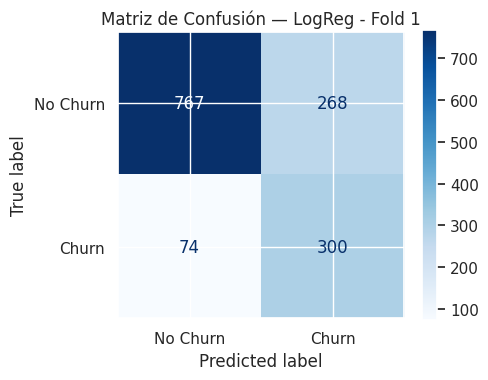


Classification Report — LogReg - Fold 1
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.82      1035
       Churn       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409


LogReg — FOLD 2/5
Mejores parámetros: {'clf__C': np.float64(0.3981071705534973), 'clf__l1_ratio': 0.75}
Mejor F1 (inner CV): 0.6249


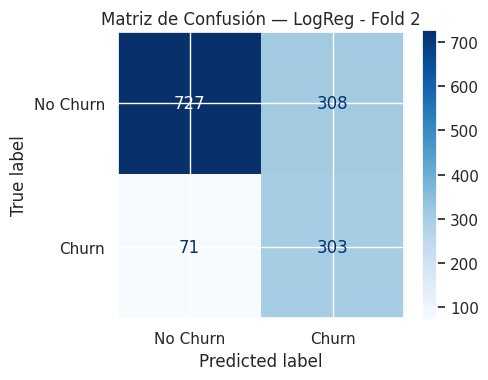


Classification Report — LogReg - Fold 2
              precision    recall  f1-score   support

    No Churn       0.91      0.70      0.79      1035
       Churn       0.50      0.81      0.62       374

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.73      0.75      1409


LogReg — FOLD 3/5
Mejores parámetros: {'clf__C': np.float64(15.848931924611142), 'clf__l1_ratio': 0}
Mejor F1 (inner CV): 0.6220


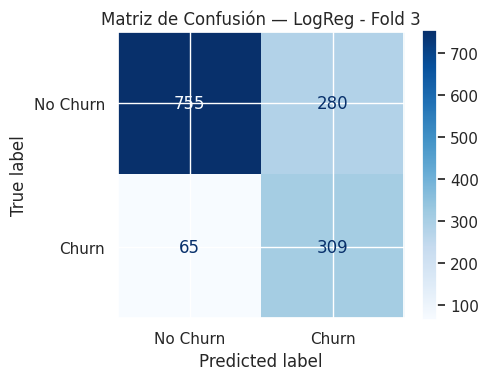


Classification Report — LogReg - Fold 3
              precision    recall  f1-score   support

    No Churn       0.92      0.73      0.81      1035
       Churn       0.52      0.83      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409


LogReg — FOLD 4/5
Mejores parámetros: {'clf__C': np.float64(15.848931924611142), 'clf__l1_ratio': 0.25}
Mejor F1 (inner CV): 0.6319


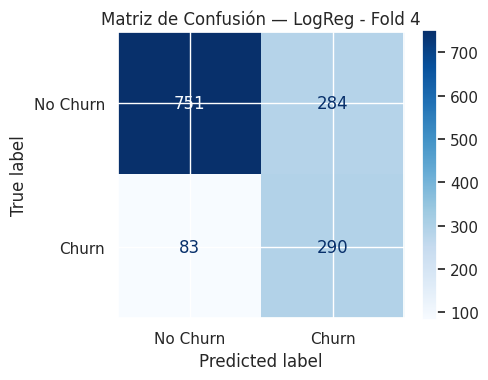


Classification Report — LogReg - Fold 4
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.51      0.78      0.61       373

    accuracy                           0.74      1408
   macro avg       0.70      0.75      0.71      1408
weighted avg       0.80      0.74      0.75      1408


LogReg — FOLD 5/5
Mejores parámetros: {'clf__C': np.float64(0.06309573444801933), 'clf__l1_ratio': 0}
Mejor F1 (inner CV): 0.6295


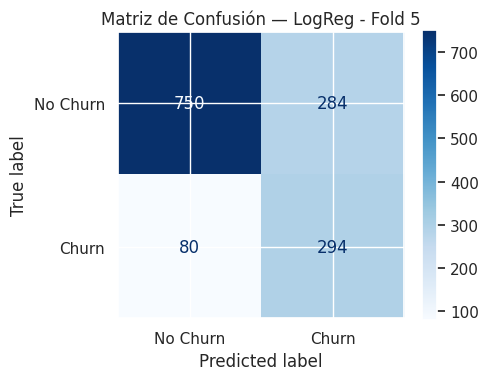


Classification Report — LogReg - Fold 5
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1034
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1408
   macro avg       0.71      0.76      0.71      1408
weighted avg       0.80      0.74      0.76      1408


RESULTADOS FINALES — LogReg
F1 por fold: [0.6369, 0.6152, 0.6417, 0.6125, 0.6176]
F1 promedio: 0.6248
F1 std     : 0.0121

Promedio métricas:
Accuracy     0.7448
Precision    0.5125
Recall       0.8004
F1-score     0.6248
ROC-AUC      0.8406
dtype: float64

███████████████████████████████████████████████████████
  EJECUTANDO NESTED CV — KNN
███████████████████████████████████████████████████████

KNN — FOLD 1/5
Mejores parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 21, 'clf__weights': 'uniform'}
Mejor F1 (inner CV): 0.5761


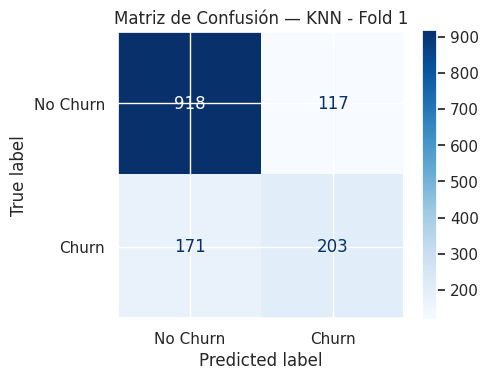


Classification Report — KNN - Fold 1
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409


KNN — FOLD 2/5
Mejores parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 29, 'clf__weights': 'distance'}
Mejor F1 (inner CV): 0.5810


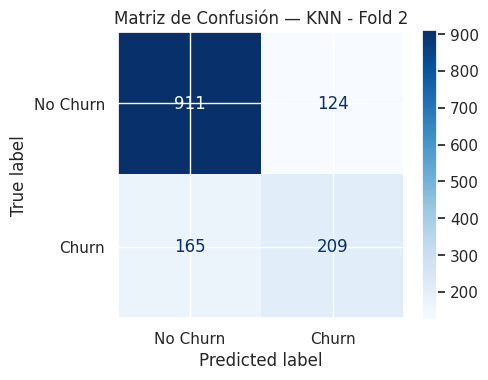


Classification Report — KNN - Fold 2
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.86      1035
       Churn       0.63      0.56      0.59       374

    accuracy                           0.79      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409


KNN — FOLD 3/5
Mejores parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 27, 'clf__weights': 'distance'}
Mejor F1 (inner CV): 0.5763


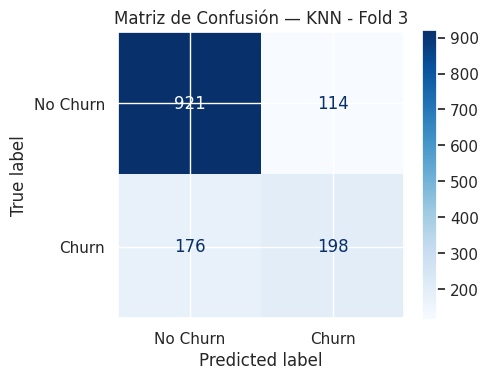


Classification Report — KNN - Fold 3
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409


KNN — FOLD 4/5
Mejores parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 23, 'clf__weights': 'uniform'}
Mejor F1 (inner CV): 0.5913


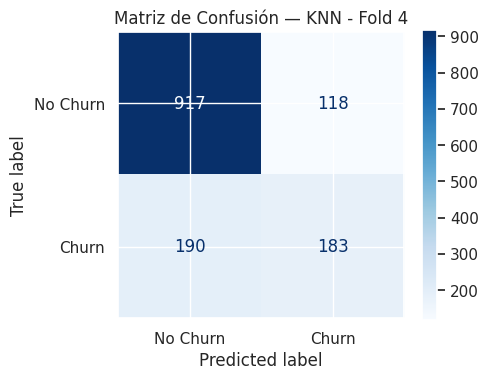


Classification Report — KNN - Fold 4
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.61      0.49      0.54       373

    accuracy                           0.78      1408
   macro avg       0.72      0.69      0.70      1408
weighted avg       0.77      0.78      0.77      1408


KNN — FOLD 5/5
Mejores parámetros: {'clf__metric': 'manhattan', 'clf__n_neighbors': 25, 'clf__weights': 'uniform'}
Mejor F1 (inner CV): 0.5831


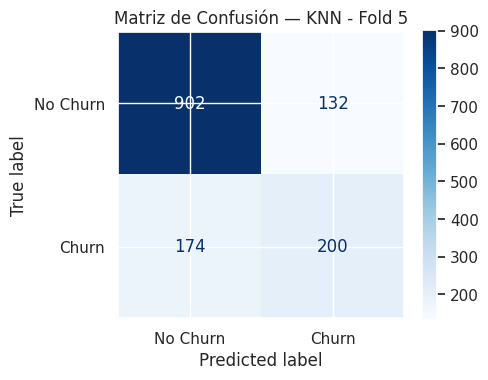


Classification Report — KNN - Fold 5
              precision    recall  f1-score   support

    No Churn       0.84      0.87      0.85      1034
       Churn       0.60      0.53      0.57       374

    accuracy                           0.78      1408
   macro avg       0.72      0.70      0.71      1408
weighted avg       0.78      0.78      0.78      1408


RESULTADOS FINALES — KNN
F1 por fold: [0.585, 0.5912, 0.5773, 0.543, 0.5666]
F1 promedio: 0.5726
F1 std     : 0.0169

Promedio métricas:
Accuracy     0.7897
Precision    0.6214
Recall       0.5313
F1-score     0.5726
ROC-AUC      0.8283
dtype: float64

███████████████████████████████████████████████████████
  EJECUTANDO NESTED CV — SVM-Lineal
███████████████████████████████████████████████████████

SVM-Lineal — FOLD 1/5
Mejores parámetros: {'clf__C': np.float64(0.00046415888336127773)}
Mejor F1 (inner CV): 0.6174


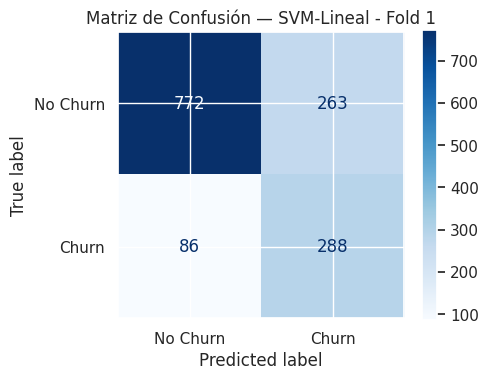


Classification Report — SVM-Lineal - Fold 1
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409


SVM-Lineal — FOLD 2/5
Mejores parámetros: {'clf__C': np.float64(0.00046415888336127773)}
Mejor F1 (inner CV): 0.6247


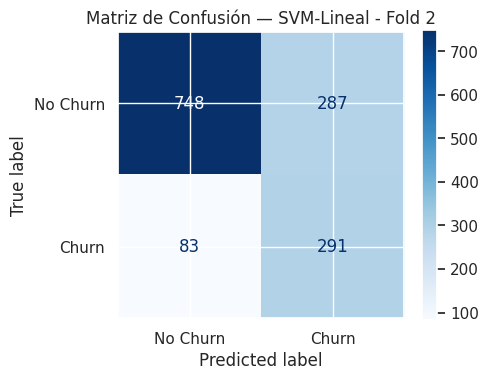


Classification Report — SVM-Lineal - Fold 2
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409


SVM-Lineal — FOLD 3/5
Mejores parámetros: {'clf__C': np.float64(0.00046415888336127773)}
Mejor F1 (inner CV): 0.6080


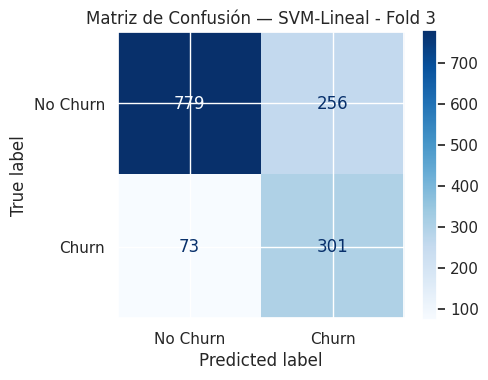


Classification Report — SVM-Lineal - Fold 3
              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.83      1035
       Churn       0.54      0.80      0.65       374

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409


SVM-Lineal — FOLD 4/5
Mejores parámetros: {'clf__C': np.float64(0.00046415888336127773)}
Mejor F1 (inner CV): 0.6268


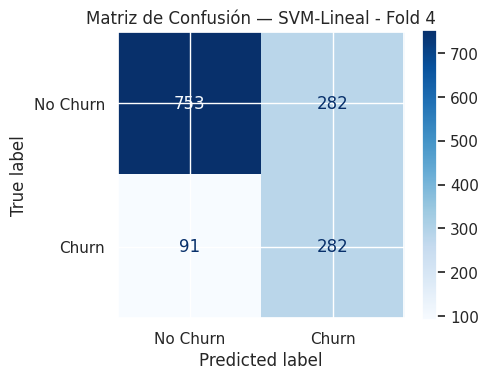


Classification Report — SVM-Lineal - Fold 4
              precision    recall  f1-score   support

    No Churn       0.89      0.73      0.80      1035
       Churn       0.50      0.76      0.60       373

    accuracy                           0.74      1408
   macro avg       0.70      0.74      0.70      1408
weighted avg       0.79      0.74      0.75      1408


SVM-Lineal — FOLD 5/5
Mejores parámetros: {'clf__C': np.float64(0.00046415888336127773)}
Mejor F1 (inner CV): 0.6222


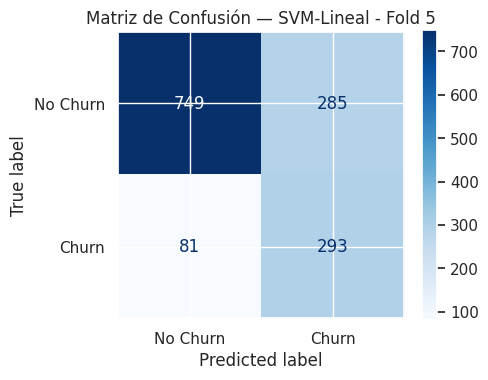


Classification Report — SVM-Lineal - Fold 5
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1034
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1408
   macro avg       0.70      0.75      0.71      1408
weighted avg       0.80      0.74      0.75      1408


RESULTADOS FINALES — SVM-Lineal
F1 por fold: [0.6227, 0.6113, 0.6466, 0.6019, 0.6155]
F1 promedio: 0.6196
F1 std     : 0.0151

Promedio métricas:
Accuracy     0.7463
Precision    0.5147
Recall       0.7785
F1-score     0.6196
ROC-AUC      0.8315
dtype: float64

███████████████████████████████████████████████████████
  EJECUTANDO NESTED CV — SVM-RBF
███████████████████████████████████████████████████████

SVM-RBF — FOLD 1/5
Mejores parámetros: {'clf__C': np.float64(10.0), 'clf__gamma': np.float64(0.01)}
Mejor F1 (inner CV): 0.6191


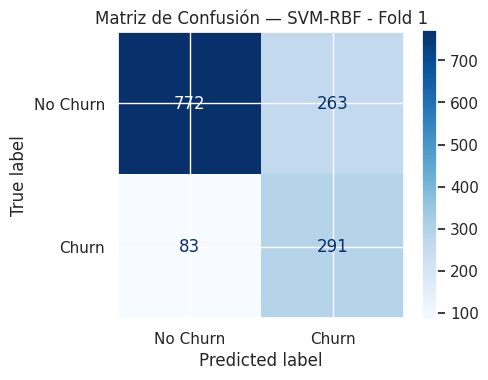


Classification Report — SVM-RBF - Fold 1
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.77      1409


SVM-RBF — FOLD 2/5
Mejores parámetros: {'clf__C': np.float64(100.0), 'clf__gamma': np.float64(0.01)}
Mejor F1 (inner CV): 0.6238


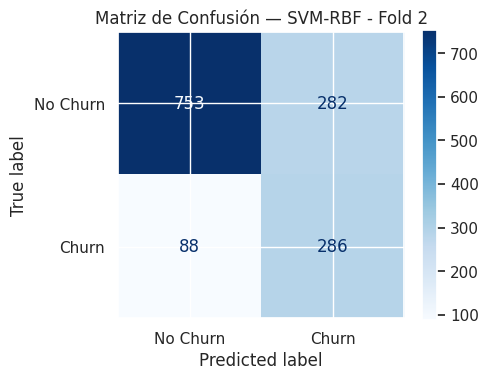


Classification Report — SVM-RBF - Fold 2
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1035
       Churn       0.50      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.74      0.75      1409


SVM-RBF — FOLD 3/5
Mejores parámetros: {'clf__C': np.float64(1.0), 'clf__gamma': np.float64(0.1)}
Mejor F1 (inner CV): 0.6199


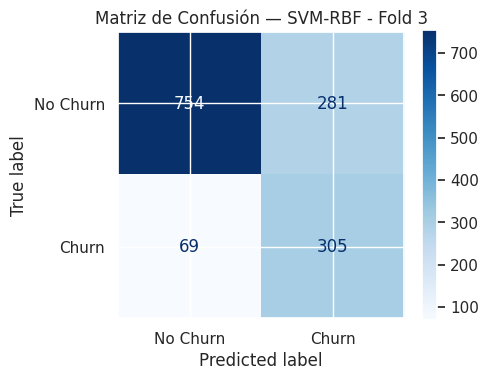


Classification Report — SVM-RBF - Fold 3
              precision    recall  f1-score   support

    No Churn       0.92      0.73      0.81      1035
       Churn       0.52      0.82      0.64       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409


SVM-RBF — FOLD 4/5
Mejores parámetros: {'clf__C': np.float64(0.1), 'clf__gamma': np.float64(0.1)}
Mejor F1 (inner CV): 0.6250


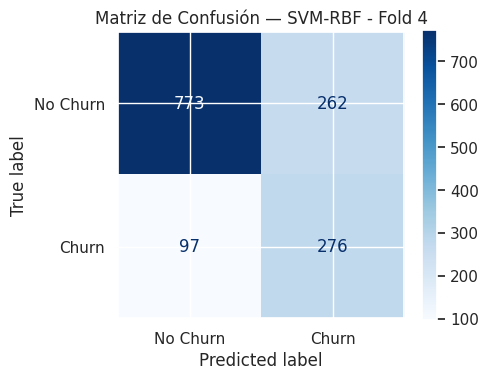


Classification Report — SVM-RBF - Fold 4
              precision    recall  f1-score   support

    No Churn       0.89      0.75      0.81      1035
       Churn       0.51      0.74      0.61       373

    accuracy                           0.75      1408
   macro avg       0.70      0.74      0.71      1408
weighted avg       0.79      0.75      0.76      1408


SVM-RBF — FOLD 5/5
Mejores parámetros: {'clf__C': np.float64(0.1), 'clf__gamma': np.float64(0.1)}
Mejor F1 (inner CV): 0.6219


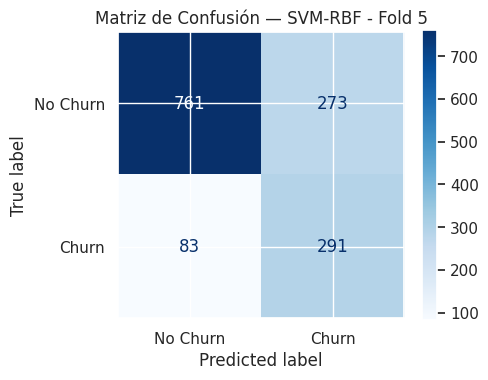


Classification Report — SVM-RBF - Fold 5
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1034
       Churn       0.52      0.78      0.62       374

    accuracy                           0.75      1408
   macro avg       0.71      0.76      0.72      1408
weighted avg       0.80      0.75      0.76      1408


RESULTADOS FINALES — SVM-RBF
F1 por fold: [0.6272, 0.6072, 0.6354, 0.6059, 0.6205]
F1 promedio: 0.6192
F1 std     : 0.0114

Promedio métricas:
Accuracy     0.7471
Precision    0.5157
Recall       0.7753
F1-score     0.6192
ROC-AUC      0.8194
dtype: float64


In [48]:
modelos = [
    ("LogReg", pipe_lr, param_grid_lr),
    ("KNN", pipe_knn, param_grid_knn),
    ("SVM-Lineal", pipe_svm_lin, param_grid_svm_lin),
    ("SVM-RBF", pipe_svm_rbf, param_grid_svm_rbf)
]

resultados = {}

for nombre, pipe, grid in modelos:

    print("\n" + "█"*55)
    print(f"  EJECUTANDO NESTED CV — {nombre}")
    print("█"*55)

    f1, params, df_metrics = nested_cv(pipe, grid, X, y, nombre)

    resultados[nombre] = {
        "f1": f1,
        "params": params,
        "metrics": df_metrics
    }


  COMPARACIÓN DE MODELOS (NESTED CV)
    Modelo  F1 media  F1 std  Accuracy  Precision  Recall  ROC-AUC
    LogReg    0.6248  0.0121    0.7448     0.5125  0.8004   0.8406
SVM-Lineal    0.6196  0.0151    0.7463     0.5147  0.7785   0.8315
   SVM-RBF    0.6192  0.0114    0.7471     0.5157  0.7753   0.8194
       KNN    0.5726  0.0169    0.7897     0.6214  0.5313   0.8283

  TESTS WILCOXON PAREADOS
LogReg       vs KNN           p=0.0625
LogReg       vs SVM-Lineal    p=0.3125
LogReg       vs SVM-RBF       p=0.1250
KNN          vs SVM-Lineal    p=0.0625
KNN          vs SVM-RBF       p=0.0625
SVM-Lineal   vs SVM-RBF       p=1.0000

  MODELO GANADOR
LogReg
F1 media: 0.6248


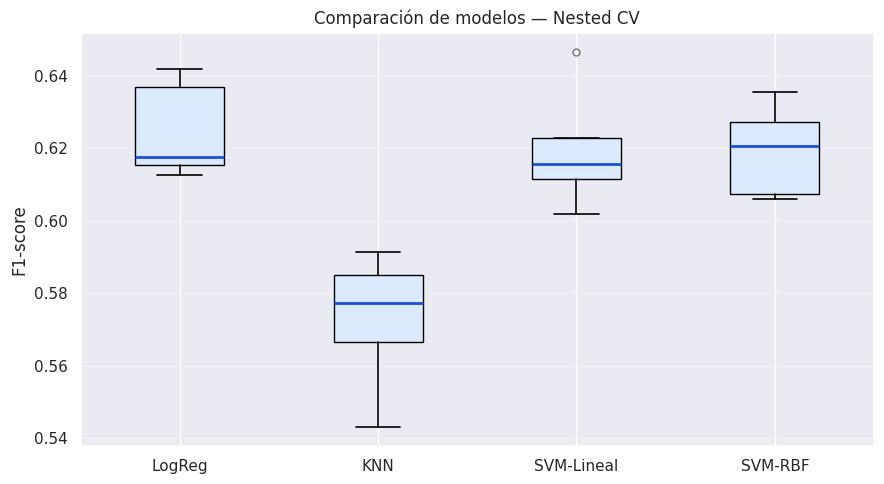

In [49]:
# ─────────────────────────────────────────────
# 1. EXTRAER DESDE "resultados"
# ─────────────────────────────────────────────

modelos = {
    nombre: resultados[nombre]["f1"]
    for nombre in resultados.keys()
}

dfs_metricas = {
    nombre: resultados[nombre]["metrics"]
    for nombre in resultados.keys()
}

nombres = list(modelos.keys())

# ─────────────────────────────────────────────
# 2. TABLA COMPARATIVA
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("  COMPARACIÓN DE MODELOS (NESTED CV)")
print("="*60)

filas = []

for nombre in nombres:

    f1_scores = modelos[nombre]
    df_m = dfs_metricas[nombre]

    filas.append({
        "Modelo": nombre,
        "F1 media":  round(np.mean(f1_scores), 4),
        "F1 std":    round(np.std(f1_scores), 4),
        "Accuracy":  round(df_m["Accuracy"].mean(), 4),
        "Precision": round(df_m["Precision"].mean(), 4),
        "Recall":    round(df_m["Recall"].mean(), 4),
        "ROC-AUC":   round(df_m["ROC-AUC"].mean(), 4),
    })

df_comparacion = (
    pd.DataFrame(filas)
    .sort_values("F1 media", ascending=False)
    .reset_index(drop=True)
)

print(df_comparacion.to_string(index=False))

# ─────────────────────────────────────────────
# 3. WILCOXON
# ─────────────────────────────────────────────

print("\n" + "="*60)
print("  TESTS WILCOXON PAREADOS")
print("="*60)

for i in range(len(nombres)):
    for j in range(i + 1, len(nombres)):

        s1 = modelos[nombres[i]]
        s2 = modelos[nombres[j]]

        stat, p = stats.wilcoxon(s1, s2)

        sig = " ← significativo (p < 0.05)" if p < 0.05 else ""
        print(f"{nombres[i]:12s} vs {nombres[j]:12s}  p={p:.4f}{sig}")

# ─────────────────────────────────────────────
# 4. GANADOR
# ─────────────────────────────────────────────

ganador = df_comparacion.iloc[0]["Modelo"]

print("\n" + "="*60)
print("  MODELO GANADOR")
print("="*60)

print(f"{ganador}")
print(f"F1 media: {df_comparacion.iloc[0]['F1 media']:.4f}")

# ─────────────────────────────────────────────
# 5. BOXPLOT
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

ax.boxplot(
    [modelos[n] for n in nombres],
    labels=nombres,
    patch_artist=True,
    boxprops=dict(facecolor="#DBEAFE"),
    medianprops=dict(color="#1D4ED8", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=5, alpha=0.5)
)

ax.set_ylabel("F1-score")
ax.set_title("Comparación de modelos — Nested CV")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
print("\n" + "="*60)
print(f"  TUNING FINAL — {ganador}")
print("="*60)

# ─────────────────────────────────────────────
# PIPELINE FINAL
# ─────────────────────────────────────────────

if ganador == "LogReg":

    pipe_final = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            max_iter=5000,
            class_weight='balanced'
        ))
    ])

    param_dist_final = {
        'clf__C': np.logspace(-3, 3, 50),
        'clf__l1_ratio': np.linspace(0, 1, 20)
    }

elif ganador == "KNN":

    pipe_final = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier())
    ])

    param_dist_final = {
        'clf__n_neighbors': list(range(3, 51, 2)),
        'clf__weights': ['uniform', 'distance'],
        'clf__metric': ['euclidean', 'manhattan']
    }

elif ganador == "SVM-Lineal":

    pipe_final = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='linear',
            class_weight='balanced',
            random_state=42
        ))
    ])

    param_dist_final = {
        'clf__C': np.logspace(-3, 3, 50)
    }

elif ganador == "SVM-RBF":

    pipe_final = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf',
            class_weight='balanced',
            random_state=42
        ))
    ])

    param_dist_final = {
        'clf__C': np.logspace(-2, 2, 30),
        'clf__gamma': np.logspace(-3, 1, 30)
    }

# ─────────────────────────────────────────────
# RANDOM SEARCH FINAL
# ─────────────────────────────────────────────

random_search = RandomizedSearchCV(
    estimator=pipe_final,
    param_distributions=param_dist_final,
    n_iter=60,
    cv=inner_cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    refit=True
)

random_search.fit(X, y)

print("\nMejores hiperparámetros:")
print(random_search.best_params_)

print(f"\nMejor F1 (CV): {random_search.best_score_:.4f}")

modelo_final = random_search.best_estimator_


  TUNING FINAL — LogReg

Mejores hiperparámetros:
{'clf__l1_ratio': np.float64(0.9473684210526315), 'clf__C': np.float64(0.012648552168552958)}

Mejor F1 (CV): 0.6268



  IMPORTANCIA DE VARIABLES — LogReg

Top 15 variables:
                      Variable  Coeficiente  Importancia_abs
                        tenure    -0.680978         0.680978
             Contract_Two year    -0.580278         0.580278
                MonthlyCharges     0.333824         0.333824
             Contract_One year    -0.275660         0.275660
              PaperlessBilling     0.160588         0.160588
   InternetService_Fiber optic     0.156124         0.156124
                     has_fiber     0.156124         0.156124
                OnlineSecurity    -0.120964         0.120964
         is_electronic_payment     0.110334         0.110334
PaymentMethod_Electronic check     0.110334         0.110334
                  TotalCharges     0.000000         0.000000
                       Partner     0.000000         0.000000
                  num_services     0.000000         0.000000
              avg_monthly_real     0.000000         0.000000
                expected_tota

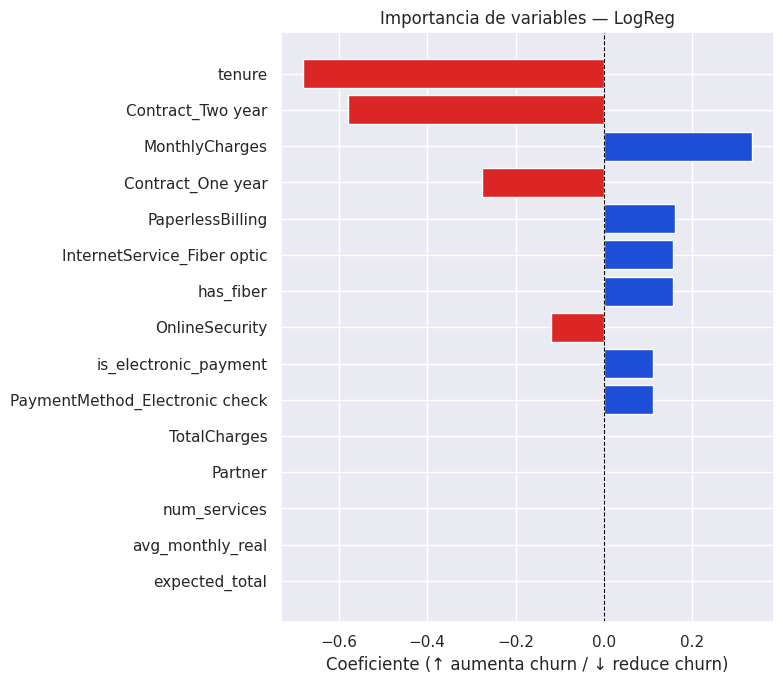

In [51]:
print(f"\n{'='*55}")
print(f"  IMPORTANCIA DE VARIABLES — {ganador}")
print(f"{'='*55}")

feature_names = X.columns.tolist()

# ─────────────────────────────────────────────
# MODELOS LINEALES (interpretables directo)
# ─────────────────────────────────────────────

if ganador in ["LogReg", "SVM-Lineal"]:

    coefs = modelo_final.named_steps['clf'].coef_[0]

    df_imp = pd.DataFrame({
        'Variable': feature_names,
        'Coeficiente': coefs,
        'Importancia_abs': np.abs(coefs)
    }).sort_values('Importancia_abs', ascending=False).reset_index(drop=True)

    print("\nTop 15 variables:")
    print(df_imp.head(15).to_string(index=False))

    top = df_imp.head(15)

    fig, ax = plt.subplots(figsize=(8, 7))
    colores = ['#1D4ED8' if c > 0 else '#DC2626' for c in top['Coeficiente']]

    ax.barh(top['Variable'][::-1], top['Coeficiente'][::-1],
            color=colores[::-1])

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f"Importancia de variables — {ganador}")
    ax.set_xlabel("Coeficiente (↑ aumenta churn / ↓ reduce churn)")

    plt.tight_layout()
    plt.show()

# ─────────────────────────────────────────────
# MODELOS NO LINEALES (Permutation Importance)
# ─────────────────────────────────────────────

else:

    result = permutation_importance(
        modelo_final,
        X, y,
        n_repeats=10,
        random_state=42,
        scoring='f1'
    )

    df_imp = pd.DataFrame({
        'Variable': feature_names,
        'Importancia': result.importances_mean,
        'Std': result.importances_std
    }).sort_values('Importancia', ascending=False).reset_index(drop=True)

    print("\nTop 15 variables:")
    print(df_imp.head(15).to_string(index=False))

    top = df_imp.head(15)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(top['Variable'][::-1], top['Importancia'][::-1],
            xerr=top['Std'][::-1],
            color='#1D4ED8', alpha=0.85,
            error_kw=dict(ecolor='gray', capsize=3))

    ax.set_title(f"Permutation Importance — {ganador}")
    ax.set_xlabel("Caída en F1 al permutar variable")

    plt.tight_layout()
    plt.show()

In [52]:
# ─────────────────────────────────────────────
# RESUMEN FINAL CORREGIDO
# ─────────────────────────────────────────────

f1_ganador = resultados[ganador]["f1"]
df_metricas_ganador = resultados[ganador]["metrics"]

col_val = 'Coeficiente' if ganador in ('LogReg', 'SVM-Lineal') else 'Importancia'

print("\n" + "█"*55)
print("  RESUMEN FINAL")
print("█"*55)

print(f"\n  DataFrame          : df  ({df.shape[0]} filas, {df.shape[1]} columnas)")
print(f"  Variable objetivo  : target_bin")
print(f"  Features           : {X.shape[1]}")
print(f"  Modelos evaluados  : LogReg, KNN, SVM-Lineal, SVM-RBF")

print(f"\n  Ranking por F1 media:")
print(df_comparacion[['Modelo', 'F1 media', 'F1 std']].to_string(index=False))

print(f"\n  Modelo ganador     : {ganador}")

print(f"  F1 medio nested CV : {np.mean(f1_ganador):.4f}")
print(f"  Std F1             : {np.std(f1_ganador):.4f}")

print("\n  Top 5 variables más importantes:")

for i, row in df_imp.head(5).iterrows():
    print(f"    {i+1}. {row['Variable']:40s}  {row[col_val]:+.4f}")


███████████████████████████████████████████████████████
  RESUMEN FINAL
███████████████████████████████████████████████████████

  DataFrame          : df  (7043 filas, 33 columnas)
  Variable objetivo  : target_bin
  Features           : 16
  Modelos evaluados  : LogReg, KNN, SVM-Lineal, SVM-RBF

  Ranking por F1 media:
    Modelo  F1 media  F1 std
    LogReg    0.6248  0.0121
SVM-Lineal    0.6196  0.0151
   SVM-RBF    0.6192  0.0114
       KNN    0.5726  0.0169

  Modelo ganador     : LogReg
  F1 medio nested CV : 0.6248
  Std F1             : 0.0121

  Top 5 variables más importantes:
    1. tenure                                    -0.6810
    2. Contract_Two year                         -0.5803
    3. MonthlyCharges                            +0.3338
    4. Contract_One year                         -0.2757
    5. PaperlessBilling                          +0.1606


PARTE FINAL

In [53]:
best_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    max_iter=5000,
    class_weight='balanced',
    C=random_search.best_params_['clf__C'],
    l1_ratio=random_search.best_params_['clf__l1_ratio']
)

final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', best_model)
])

final_pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(C=np.float64(0.012648552168552958),
                                    class_weight='balanced',
                                    l1_ratio=np.float64(0.9473684210526315),
                                    max_iter=5000, penalty='elasticnet',
                                    solver='saga'))])

Hiperparámetros óptimos
C = random_search.best_params_['clf__C']
l1_ratio = random_search.best_params_['clf__l1_ratio']

✔ Estos vienen del RandomizedSearchCV final
✔ Son los mejores encontrados en CV

In [54]:
y_pred = final_pipeline.predict(X)
y_score = final_pipeline.predict_proba(X)[:, 1]

print(classification_report(y, y_pred))
roc_auc_score(y, y_score)

              precision    recall  f1-score   support

           0       0.91      0.72      0.81      5174
           1       0.51      0.81      0.63      1869

    accuracy                           0.74      7043
   macro avg       0.71      0.76      0.72      7043
weighted avg       0.81      0.74      0.76      7043



np.float64(0.8380092937006719)